# QuadraticRNN on Discrete $SE(2)$ — Analysis from a saved run

Sibling of `discrete_se2_rnn.ipynb`, but **no training**. Point `RUN_DIR` at a
run directory produced by `python -m trained_networks.main --config ...` (or one of the
`seed_<S>/` subfolders inside a sweep result) and run all cells.

What we load:

- `config.yaml`            — to rebuild the model & instantiate the group
- `template.npy`           — the input template used during training
- `train_loss_history.npy` — for the loss curve
- `val_loss_history.npy`   — overlaid on the loss curve
- `param_history.pt`       — for power-spectrum-over-training (sparse snapshots)
- `param_save_indices.npy` — the actual training steps those snapshots came from
- `checkpoints/final_model.pt` — for the output-weights analysis


## Set up

### Imports

In [16]:
%load_ext autoreload
%autoreload 2

import os
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import torch
import yaml

from src.groups import DiscreteSE2Group
import trained_networks.dataset as dataset
import trained_networks.model as model
import src.template as template
import trained_networks.viz as viz

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Pick the run directory

In [28]:
# Edit this. Either a single-run dir produced by `python -m trained_networks.main ...`
# or a `<sweep>/<exp>/seed_<S>` dir from a sweep result.

#RUN_DIR = Path("/home/facosta/group-agf/sweep_results/sweep_discrete_se2_n_k_20260423_024701/k4_p15/seed_0")
RUN_DIR = Path("/home/facosta/group-agf/sweep_results/sweep_discrete_se2_n_k_20260423_024701/k2_p10/seed_0")

assert RUN_DIR.exists(), f"RUN_DIR does not exist: {RUN_DIR}"
print(f"Loading from: {RUN_DIR.resolve()}")

Loading from: /data/facosta/sweep_results/sweep_discrete_se2_n_k_20260423_024701/k2_p10/seed_0


### Device & figure I/O

In [29]:
# Analysis defaults to CPU (loading + plotting; no training).
# Bump to "cuda:0" if you want power-spectrum eval to run on GPU.
device_name = "cuda:0"
device = torch.device(device_name if not device_name.startswith("cuda") or torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

SAVE_FIGS = False
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

Using device: cuda:0


### Load config

In [30]:
with open(RUN_DIR / "config.yaml") as f:
    config = yaml.safe_load(f)

print(yaml.dump({k: config[k] for k in ("data", "model", "training") if k in config},
                default_flow_style=False, sort_keys=False))

data:
  batch_size: 8192
  group_name: znxzn_cm
  k: 2
  m: 3
  mode: sampled
  num_samples: 1000
  p: 10
  powers: null
  seed: 0
  template_type: onehot
model:
  hidden_dim: 3000
  init_scale: 0.05
  model_type: QuadraticRNN
  nonlinearity: square
  output_scale: 1.0
  return_all_outputs: true
training:
  betas:
  - 0.9
  - 0.999
  degree: null
  epochs: 1000
  grad_clip: 0.1
  learning_rate: 0.001
  mode: online
  num_steps: 10000
  optimizer: adam
  reduction_threshold: 0.99
  resume_from: null
  save_param_interval: 2000
  save_param_snapshots: true
  scaling_factor: -3
  verbose_interval: 250
  weight_decay: 0.0



## Group

In [31]:
assert config["data"]["group_name"] == "znxzn_cm", (
    f"This notebook is specialized to DiscreteSE2Group; got group_name="
    f"{config['data']['group_name']!r}"
)
n = int(config["data"]["p"])     # translation period
m = int(config["data"]["m"])     # rotation order
k = int(config["data"]["k"])

group = DiscreteSE2Group(n=n, m=m)
group_size = group.order
irreps = group.irreps()
n_irreps = len(irreps)

group_label = f"Z_{n}^2 ⋊ C_{m}"
group_label_latex = f"$\\mathbb{{Z}}_{{{n}}}^2 \\rtimes C_{{{m}}}$"
file_tag = f"discrete_se2_n{n}_m{m}_k{k}_analysis"

print(f"Group: {group_label}, |G| = {group_size}, k = {k}")
print(f"#irreps = {n_irreps}")

Group: Z_10^2 ⋊ C_3, |G| = 300, k = 2
#irreps = 36


## Load template

In [32]:
tpl = np.load(RUN_DIR / "template.npy").astype(np.float32)
assert tpl.shape == (group_size,), (
    f"template shape {tpl.shape} doesn't match |G|={group_size}; "
    "config and run dir are inconsistent"
)
print(f"template shape: {tpl.shape}, dtype: {tpl.dtype}")
print(f"template_type (config): {config['data'].get('template_type')!r}")

template shape: (300,), dtype: float32
template_type (config): 'onehot'


## Reconstruct the model and load the final checkpoint

In [33]:
hidden_dim = int(config["model"]["hidden_dim"])
init_scale = float(config["model"]["init_scale"])
return_all_outputs = bool(config["model"].get("return_all_outputs", False))

assert config["model"]["model_type"] == "QuadraticRNN", (
    f"This notebook expects QuadraticRNN; got {config['model']['model_type']!r}"
)

net = model.QuadraticRNN(
    group_size=group_size,
    hidden_dim=hidden_dim,
    k=k,
    init_scale=init_scale,
    return_all_outputs=return_all_outputs,
)

state = torch.load(RUN_DIR / "checkpoints" / "final_model.pt", map_location=device, weights_only=False)
net.load_state_dict(state)
net = net.to(device).eval()

n_params = sum(p.numel() for p in net.parameters())
print(f"Loaded QuadraticRNN(hidden_dim={hidden_dim}, k={k}, return_all_outputs={return_all_outputs})")
print(f"  total params: {n_params:,}")

Loaded QuadraticRNN(hidden_dim=3000, k=2, return_all_outputs=True)
  total params: 11,700,000


## Load training histories and parameter snapshots

In [34]:
loss_history = np.load(RUN_DIR / "train_loss_history.npy")
val_loss_history = np.load(RUN_DIR / "val_loss_history.npy")
print(f"loss_history: {loss_history.shape}, val_loss_history: {val_loss_history.shape}")

param_history_path = RUN_DIR / "param_history.pt"
if param_history_path.exists():
    param_history = torch.load(param_history_path, map_location="cpu", weights_only=False)
    param_save_indices = np.load(RUN_DIR / "param_save_indices.npy")
    print(f"param_history: {len(param_history)} snapshots at steps {list(param_save_indices)}")
else:
    param_history = [{n_: p.detach().cpu().clone() for n_, p in net.named_parameters()}]
    param_save_indices = np.array([len(loss_history) - 1], dtype=np.int64)
    print("No param_history.pt; using final-checkpoint snapshot only.")

loss_history: (727,), val_loss_history: (727,)
param_history: 2 snapshots at steps [0, 726]


## Build a small evaluation batch (for power-spectrum-over-time)

In [35]:
# `viz.model_power_over_time` only needs a few inputs to evaluate the
# learned function at each snapshot. Use the generic online dataset on CPU
# and pull one batch.
EVAL_BATCH = 256
eval_ds = dataset.GroupCompositionDataset(
    group,
    online=True,
    template=tpl,
    k=k,
    batch_size=EVAL_BATCH,
    device=str(device),
    return_all_outputs=return_all_outputs,
)
X_tensor, Y_tensor = next(iter(eval_ds))
print(f"X_tensor: {tuple(X_tensor.shape)}  Y_tensor: {tuple(Y_tensor.shape)}")

X_tensor: (256, 2, 300)  Y_tensor: (256, 1, 300)


## Training Loss with theory horizontal lines

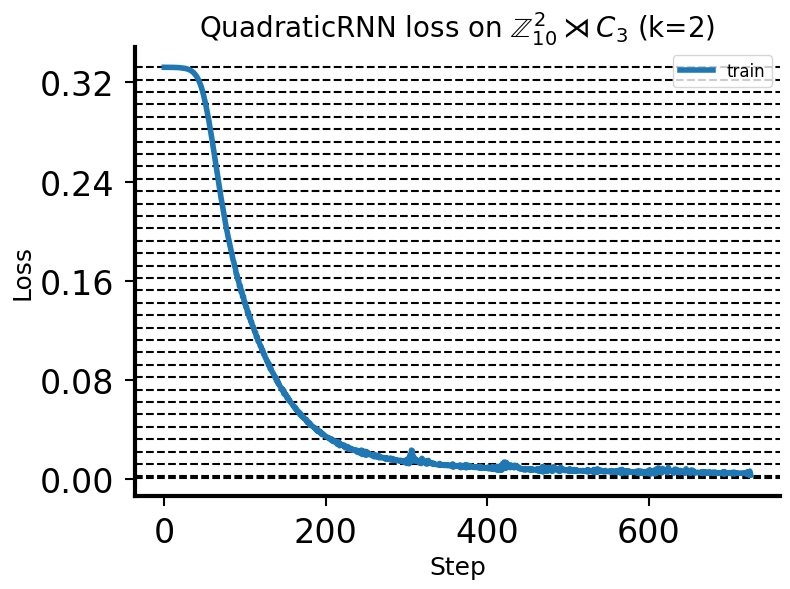

In [36]:
theory_levels = viz.loss_plateau_predictions(tpl, group)

x = (param_save_indices if config["training"].get("mode") == "online"
     else np.arange(len(loss_history)))
xlabel = "Step" if config["training"].get("mode") == "online" else "Epoch"

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(loss_history, lw=4, label="train")
# if len(val_loss_history) == len(loss_history):
#     ax.plot(val_loss_history, lw=2, alpha=0.7, label="val")

for level in theory_levels[:-1]:
    ax.axhline(y=level, color="black", linestyle="--", linewidth=1.5, zorder=-2)

ax.set_xlabel(xlabel, fontsize=18)
ax.set_ylabel("Loss", fontsize=18)
# ax.set_yscale("log")
ax.set_title(f"QuadraticRNN loss on {group_label_latex} (k={k})", fontsize=20)
ax.legend(fontsize=12)
viz.style_axes(ax)
ax.grid(False)
plt.tight_layout()

if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_loss.pdf", bbox_inches="tight")
plt.show()

## Output weights Analysis 

### Extract Output Weights

In [37]:
t = -1                       # last snapshot
param_name = "W_out"         # readout weights

W_all = param_history[t][param_name].detach().cpu().numpy()
n_group_elements, n_neurons = W_all.shape
print(f"W_out shape: {W_all.shape}  (group_size={group_size}, hidden={hidden_dim})")

W_out shape: (300, 3000)  (group_size=300, hidden=3000)


### Rotation-averaged grid overview

/tmp/ipykernel_2937409/856598875.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


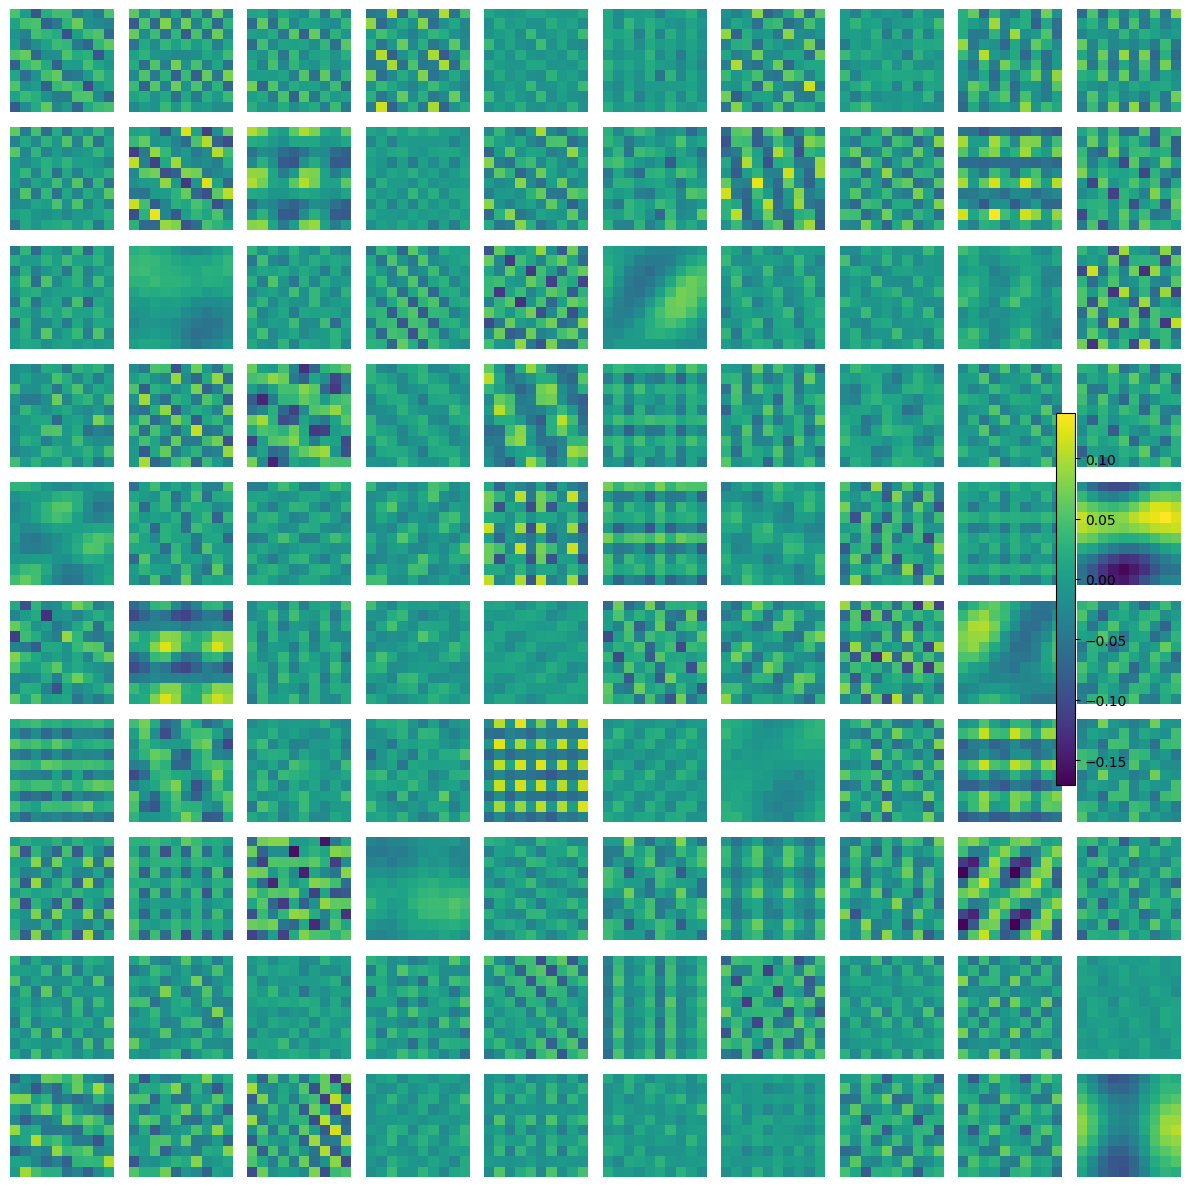

In [38]:
rows, cols = 10, 10
max_neurons_to_show = min(rows * cols, n_neurons)

images = []
for idx in range(max_neurons_to_show):
    w = W_all[:, idx]
    images.append(w.reshape(m, n, n).sum(axis=0))   # marginalize rotations

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = np.asarray(axes).reshape(rows, cols)
im = None
for idx, ax in enumerate(axes.flat):
    if idx < len(images):
        im = ax.imshow(images[idx], cmap="viridis", norm=norm)
    ax.axis("off")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_grid.pdf", bbox_inches="tight")
plt.show()

### Bucket neurons by dominant irrep

In [40]:
K_MAX = 8
elems = group.elements()


def neuron_rot_marg(w):
    return w.reshape(m, n, n).sum(axis=0)            # (n, n)


def neuron_trans_marg(w):
    return w.reshape(m, n, n).sum(axis=(1, 2))       # (m,)


def _irrep_full(irrep):
    M = np.array([irrep(g) for g in elems])
    if M.ndim == 1:
        M = M[:, None, None]
    return M                                         # (|G|, d, d)


def theory_rot_marg(irrep):
    M = _irrep_full(irrep)
    chi = np.trace(M, axis1=-2, axis2=-1)            # character (basis-invariant)
    return chi.real.reshape(m, n, n).sum(axis=0)     # (n, n)


def theory_trans_marg(irrep):
    M = _irrep_full(irrep)
    chi = np.trace(M, axis1=-2, axis2=-1)
    return chi.real.reshape(m, n, n).sum(axis=(1, 2))  # (m,)


n_neurons = W_all.shape[1]


neuron_imgs = np.stack([neuron_rot_marg(W_all[:, h]) for h in range(n_neurons)])
neuron_vecs = np.stack([neuron_trans_marg(W_all[:, h]) for h in range(n_neurons)])

ps = np.stack([group.power_spectrum(W_all[:, h]) for h in range(n_neurons)])
dom = ps.argmax(axis=1)
power_at_dom = ps[np.arange(n_neurons), dom]
neurons_by_irrep = {
    gid: np.where(dom == gid)[0][np.argsort(-power_at_dom[dom == gid])][:K_MAX].tolist()
    for gid in range(n_irreps)
}
counts = {gid: int((dom == gid).sum()) for gid in range(n_irreps)}
print(f"Neurons per dominant irrep: {dict(sorted(counts.items()))}")

Neurons per dominant irrep: {0: 0, 1: 9, 2: 10, 3: 77, 4: 73, 5: 78, 6: 87, 7: 114, 8: 100, 9: 105, 10: 111, 11: 103, 12: 92, 13: 97, 14: 112, 15: 116, 16: 72, 17: 71, 18: 85, 19: 86, 20: 93, 21: 115, 22: 98, 23: 85, 24: 97, 25: 81, 26: 88, 27: 113, 28: 76, 29: 68, 30: 93, 31: 91, 32: 62, 33: 79, 34: 87, 35: 76}


### Rotation-marginal display

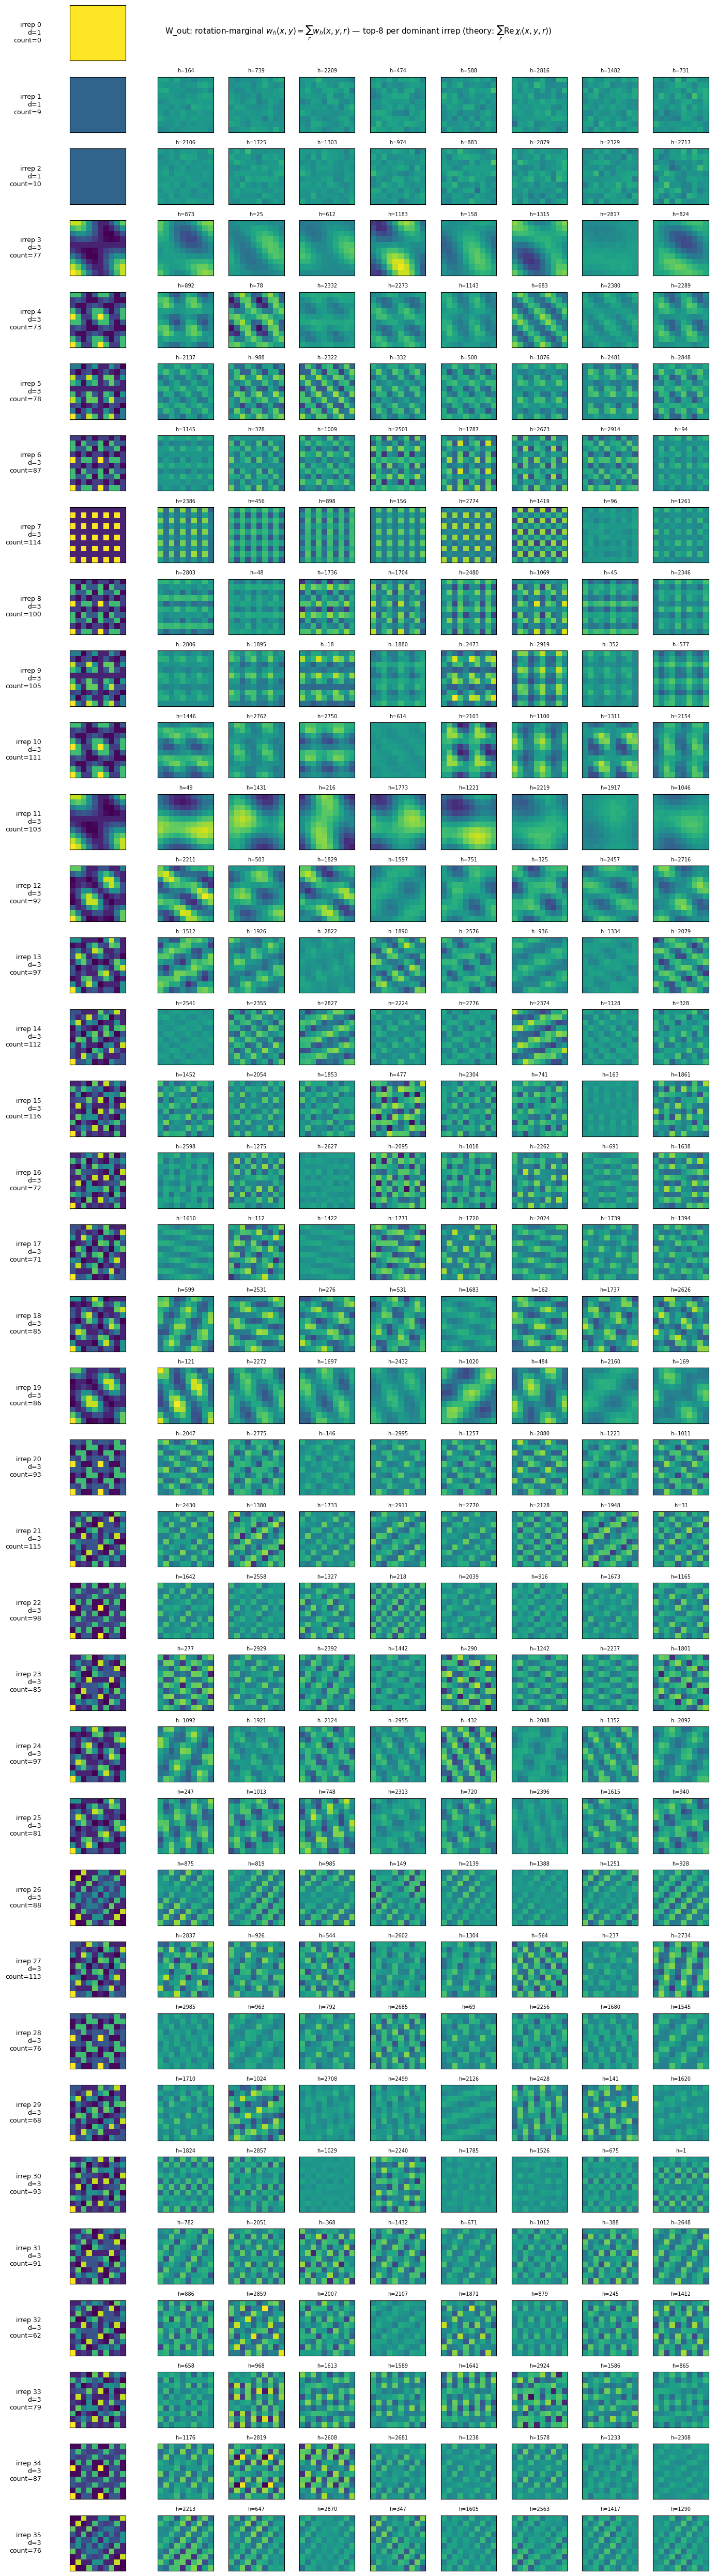

In [45]:
theory_imgs = [theory_rot_marg(ir) for ir in irreps]
norm_n  = Normalize(vmin=neuron_imgs.min(), vmax=neuron_imgs.max())
norm_th = Normalize(vmin=min(t.min() for t in theory_imgs),
                    vmax=max(t.max() for t in theory_imgs))

nrows = n_irreps
ncols = 2 + K_MAX
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.4 * ncols, 1.4 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(n_irreps)):
    ax_th = axes[r, 0]
    ax_th.imshow(theory_imgs[gid], cmap="viridis", norm=norm_th, origin="lower")
    ax_th.set_xticks([]); ax_th.set_yticks([])
    ax_th.set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                     rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            h = bucket[c]
            ax.imshow(neuron_imgs[h], cmap="viridis", norm=norm_n, origin="lower")
            ax.set_title(f"h={h}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")
fig.suptitle(
    rf"{param_name}: rotation-marginal $w_h(x,y) = \sum_r w_h(x,y,r)$ — top-{K_MAX} per dominant irrep "
    rf"(theory: $\sum_r \mathrm{{Re}}\,\chi_i(x,y,r)$)",
    fontsize=11,
)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_rot.pdf", bbox_inches="tight")
plt.show()


### Translation-marginal display

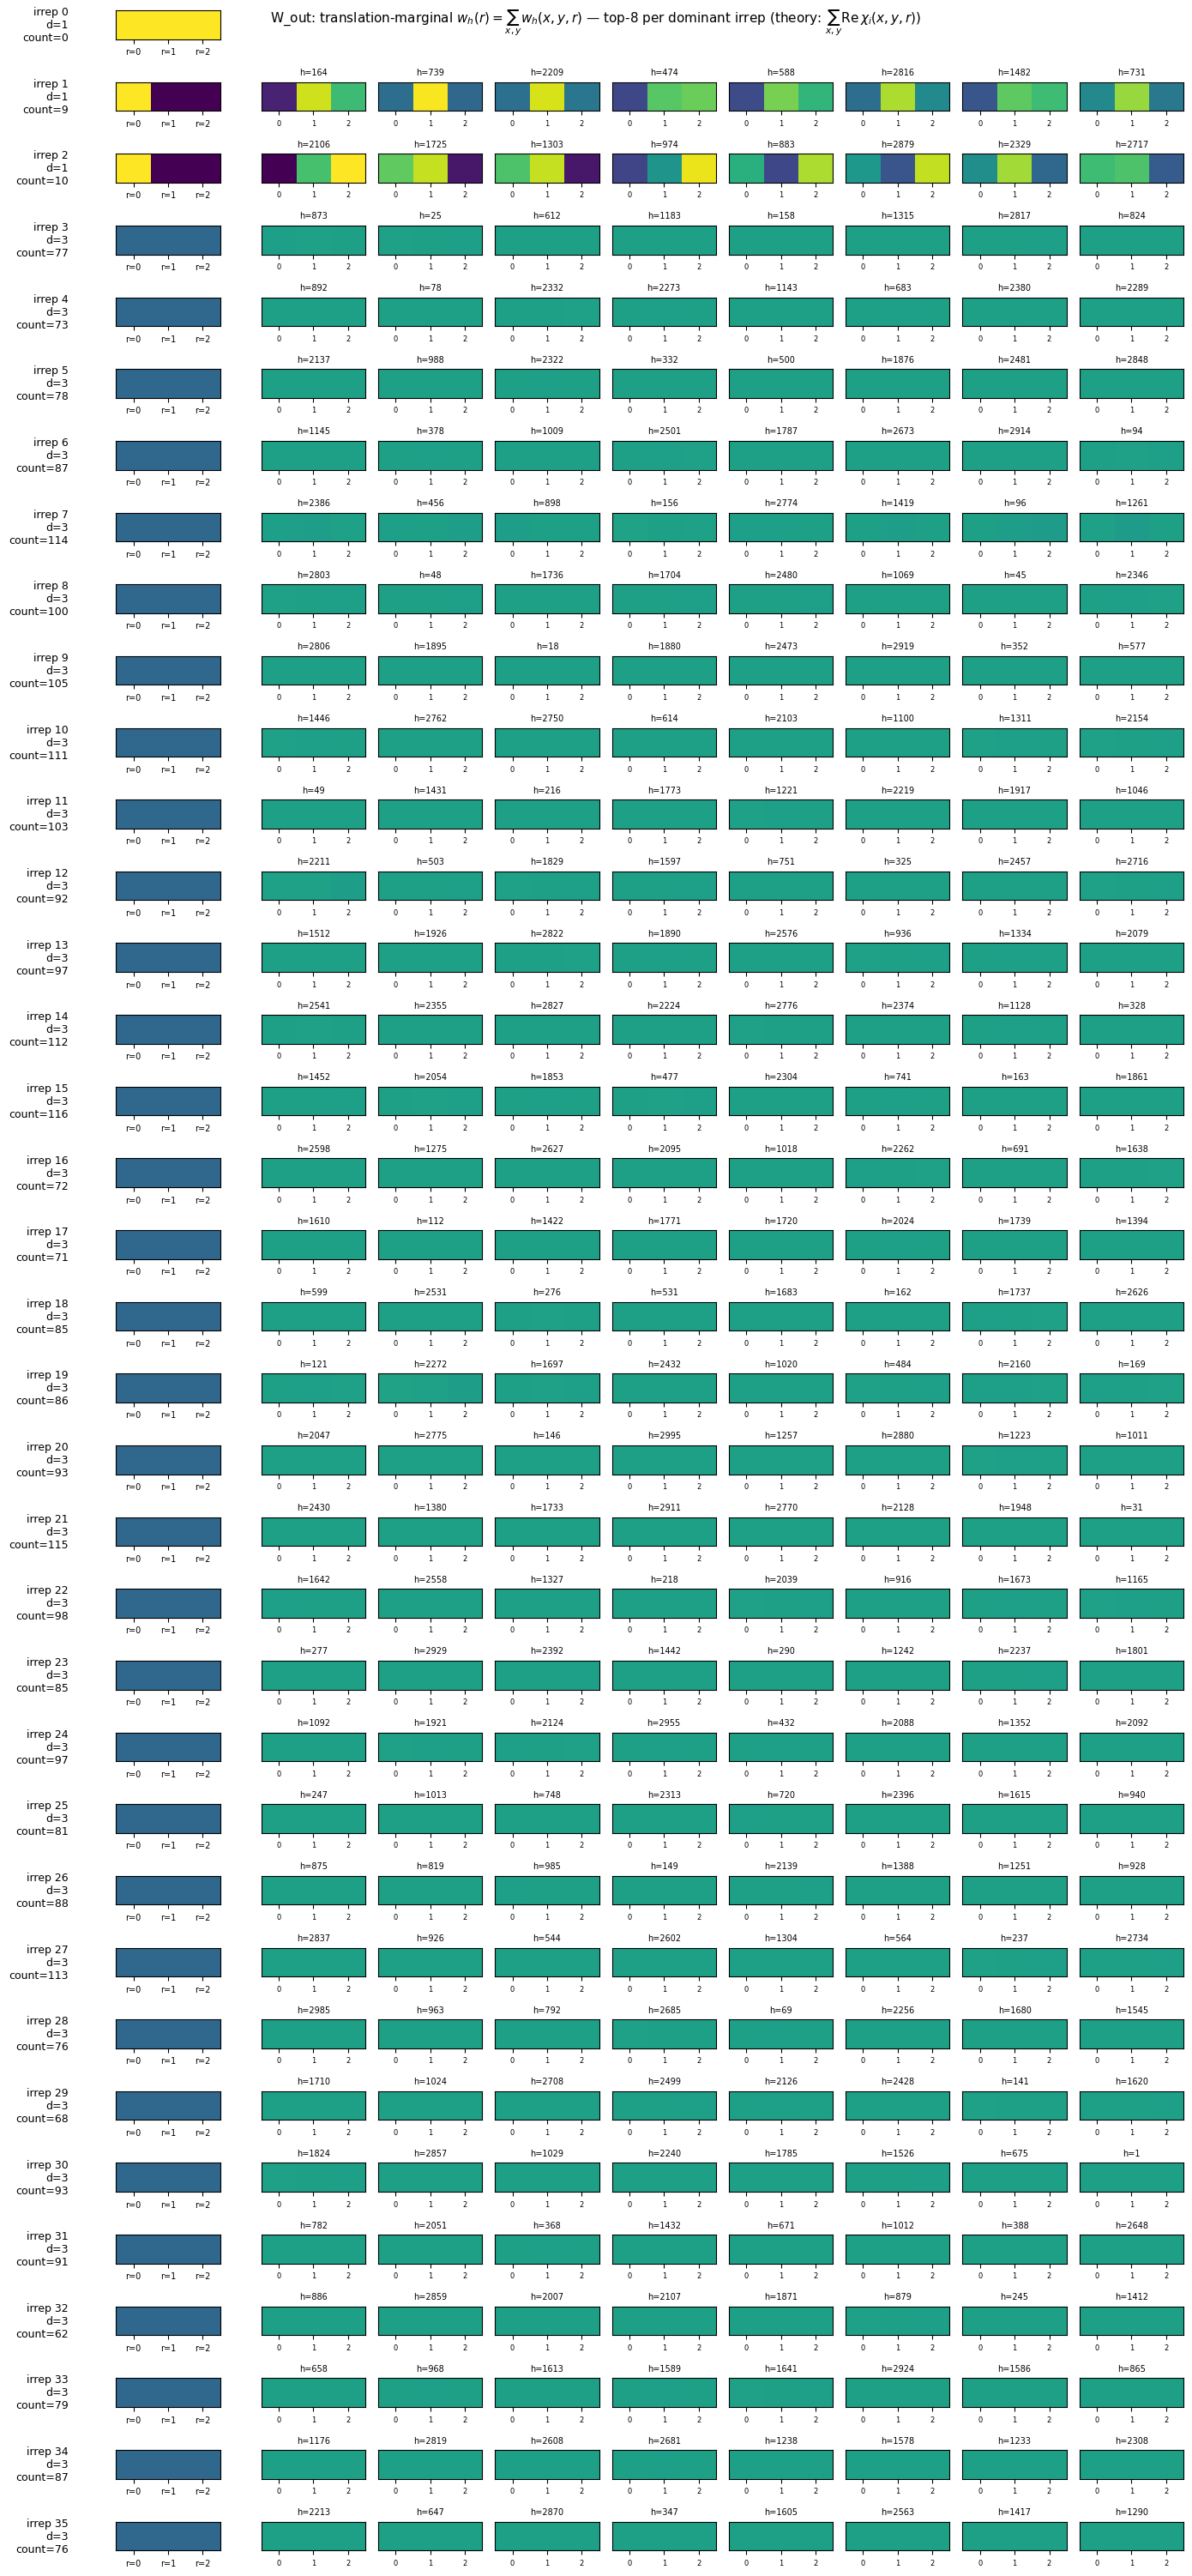

In [46]:
theory_vecs = np.stack([theory_trans_marg(ir) for ir in irreps])

norm_n  = Normalize(vmin=neuron_vecs.min(), vmax=neuron_vecs.max())
norm_th = Normalize(vmin=theory_vecs.min(), vmax=theory_vecs.max())

nrows = n_irreps
ncols = 2 + K_MAX
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(1.4 * ncols, 0.85 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(n_irreps)):
    ax_th = axes[r, 0]
    ax_th.imshow(theory_vecs[gid][None, :], cmap="viridis", norm=norm_th, aspect="auto")
    ax_th.set_xticks(range(m)); ax_th.set_xticklabels([f"r={i}" for i in range(m)], fontsize=7)
    ax_th.set_yticks([])
    ax_th.set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                     rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            h = bucket[c]
            ax.imshow(neuron_vecs[h][None, :], cmap="viridis", norm=norm_n, aspect="auto")
            ax.set_title(f"h={h}", fontsize=7)
            ax.set_xticks(range(m)); ax.set_xticklabels([str(i) for i in range(m)], fontsize=6)
            ax.set_yticks([])
        else:
            ax.axis("off")
fig.suptitle(
    rf"{param_name}: translation-marginal $w_h(r) = \sum_{{x,y}} w_h(x,y,r)$ — top-{K_MAX} per dominant irrep "
    rf"(theory: $\sum_{{x,y}} \mathrm{{Re}}\,\chi_i(x,y,r)$)",
    fontsize=11,
)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_trans.pdf", bbox_inches="tight")
plt.show()

### Rotation-sliced display

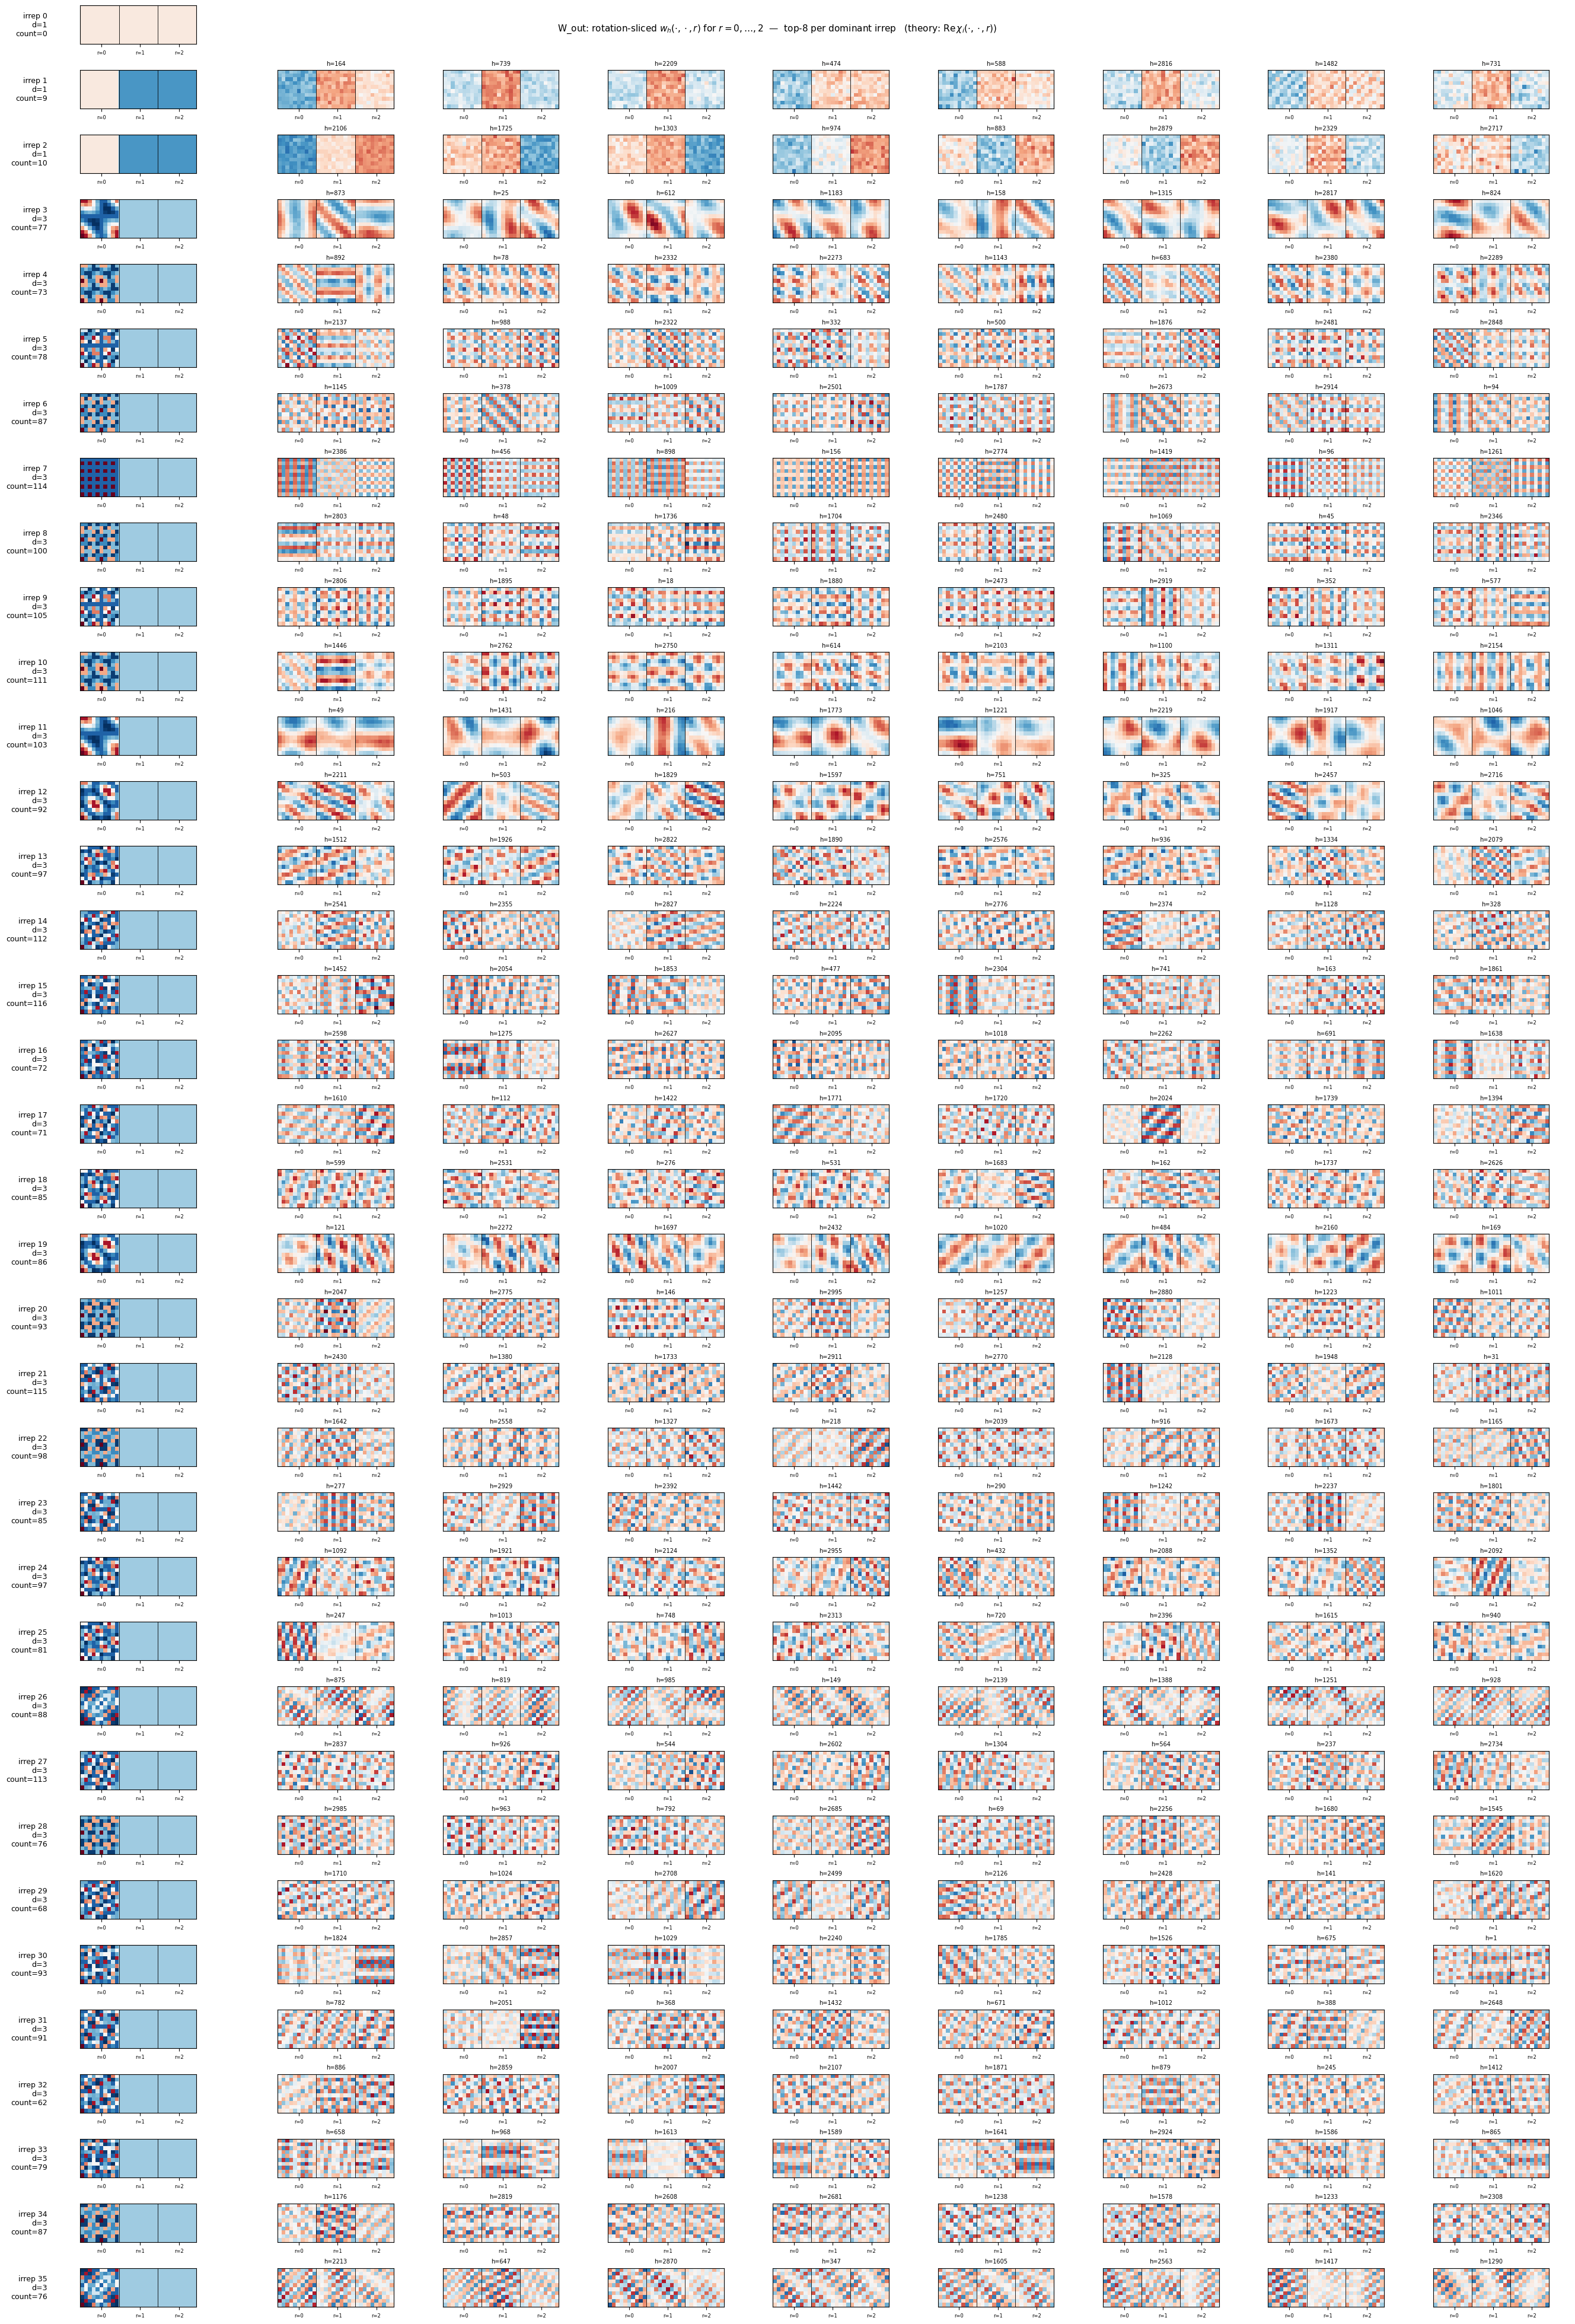

In [64]:
def neuron_slices(w):
    return np.concatenate(list(w.reshape(m, n, n)), axis=1)


def theory_slices(irrep):
    M = _irrep_full(irrep)
    chi = np.trace(M, axis1=-2, axis2=-1).real
    return np.concatenate(list(chi.reshape(m, n, n)), axis=1)


neuron_sl = np.stack([neuron_slices(W_all[:, h]) for h in range(n_neurons)])
theory_sl = [theory_slices(ir) for ir in irreps]

norm_n  = Normalize(vmin=neuron_sl.min(), vmax=neuron_sl.max())
norm_th = Normalize(vmin=min(t.min() for t in theory_sl),
                    vmax=max(t.max() for t in theory_sl))


def _draw_tile(ax, img, norm, title=None):
    ax.imshow(img, cmap="RdBu_r", norm=norm, origin="lower", aspect="equal")
    for k_ in range(1, m):
        ax.axvline(k_ * n - 0.5, color="black", lw=0.6)
    ax.set_xticks([n // 2 + i * n for i in range(m)])
    ax.set_xticklabels([f"r={i}" for i in range(m)], fontsize=6)
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=7)


nrows = n_irreps
ncols = 2 + K_MAX
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(0.9 * m * ncols, 1.1 * nrows),
    squeeze=False,
    gridspec_kw={"width_ratios": [1.0, 0.15] + [1.0] * K_MAX},
)
for r, gid in enumerate(range(n_irreps)):
    _draw_tile(axes[r, 0], theory_sl[gid], norm_th)
    axes[r, 0].set_ylabel(f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
                          rotation=0, ha="right", va="center", labelpad=40, fontsize=9)
    axes[r, 1].axis("off")
    bucket = neurons_by_irrep[gid]
    for c in range(K_MAX):
        ax = axes[r, c + 2]
        if c < len(bucket):
            _draw_tile(ax, neuron_sl[bucket[c]], norm_n, title=f"h={bucket[c]}")
        else:
            ax.axis("off")

fig.suptitle(
    rf"{param_name}: rotation-sliced $w_h(\cdot, \cdot, r)$ for $r=0,\ldots,{m-1}$  —  "
    rf"top-{K_MAX} per dominant irrep   (theory: $\mathrm{{Re}}\,\chi_i(\cdot, \cdot, r)$)",
    fontsize=11,
)
plt.tight_layout()
#if SAVE_FIGS:
plt.savefig(f"{FIGURES_DIR}/{file_tag}_weights_by_irrep_slices.pdf", bbox_inches="tight")
plt.show()

### Compute neuron tuning curves over G

In [55]:
# === Hidden-neuron tuning curves over G (compute) ===
#
# For each g in G, probe the network with x_seq = (x_g, x_e, ..., x_e)
# of length k. Cumulative product is g at every step, so the final hidden
# state h(g) is the network's representation of "I'm at position g".
# We extract h itself (not W_out @ h) by replaying the forward pass.
import torch

NORMALIZE_PER_NEURON = True   # rescale each neuron's map by its own peak

assert hasattr(eval_ds, "shift") and hasattr(eval_ds, "template_gpu"), (
    "Expected the generic online dataset (with .shift / .template_gpu). "
    "Re-run the eval-dataset cell with online=True."
)

G = group.order
all_g = torch.arange(G, device=eval_ds.device)
x_g_all   = eval_ds.template_gpu[eval_ds.shift[all_g]]   # (G, G):  x_g for every g
x_e       = eval_ds.template_gpu                          # (G,):    template at identity
x_e_batch = x_e.expand(G, -1)                             # (G, G)

# Probe sequence (x_g, x_e, x_e, ..., x_e), length k
if k == 2:
    x_seq = torch.stack([x_g_all, x_e_batch], dim=1)            # (G, 2, G)
else:
    rest  = x_e_batch.unsqueeze(1).expand(G, k - 1, G)
    x_seq = torch.cat([x_g_all.unsqueeze(1), rest], dim=1)      # (G, k, G)

# Replay QuadraticRNN forward, but stop at the hidden state.
sigma = lambda z: z ** 2
net.eval()
with torch.no_grad():
    h = sigma(x_seq[:, 0] @ net.W_in.T + x_seq[:, 1] @ net.W_drive.T)   # (G, hidden)
    for t in range(2, k):
        h = sigma(h @ net.W_mix.T + x_seq[:, t] @ net.W_drive.T)
    H = h.cpu().numpy()                                                  # (G, n_neurons)

# Reshape over (rotation, x, y) — same convention as the weight-viz cells.
H_rxy        = H.T.reshape(n_neurons, m, n, n)                            # (H, m, n, n)
trans_tuning = H_rxy.mean(axis=1)                                         # (H, n, n)  rate_j(x,y)
rot_tuning   = H_rxy.mean(axis=(2, 3))                                    # (H, m)     for later if you want it

if NORMALIZE_PER_NEURON:
    peaks = trans_tuning.reshape(n_neurons, -1).max(axis=1)
    peaks = np.where(peaks > 1e-12, peaks, 1.0)
    trans_tuning_show = trans_tuning / peaks[:, None, None]
else:
    trans_tuning_show = trans_tuning

print(f"H: {H.shape}     range [{H.min():.3g}, {H.max():.3g}]  mean {H.mean():.3g}")
print(f"trans_tuning: {trans_tuning.shape}   (per-neuron 2D translation rate maps)")

H: (300, 3000)     range [2.88e-13, 5.59]  mean 0.416
trans_tuning: (3000, 10, 10)   (per-neuron 2D translation rate maps)


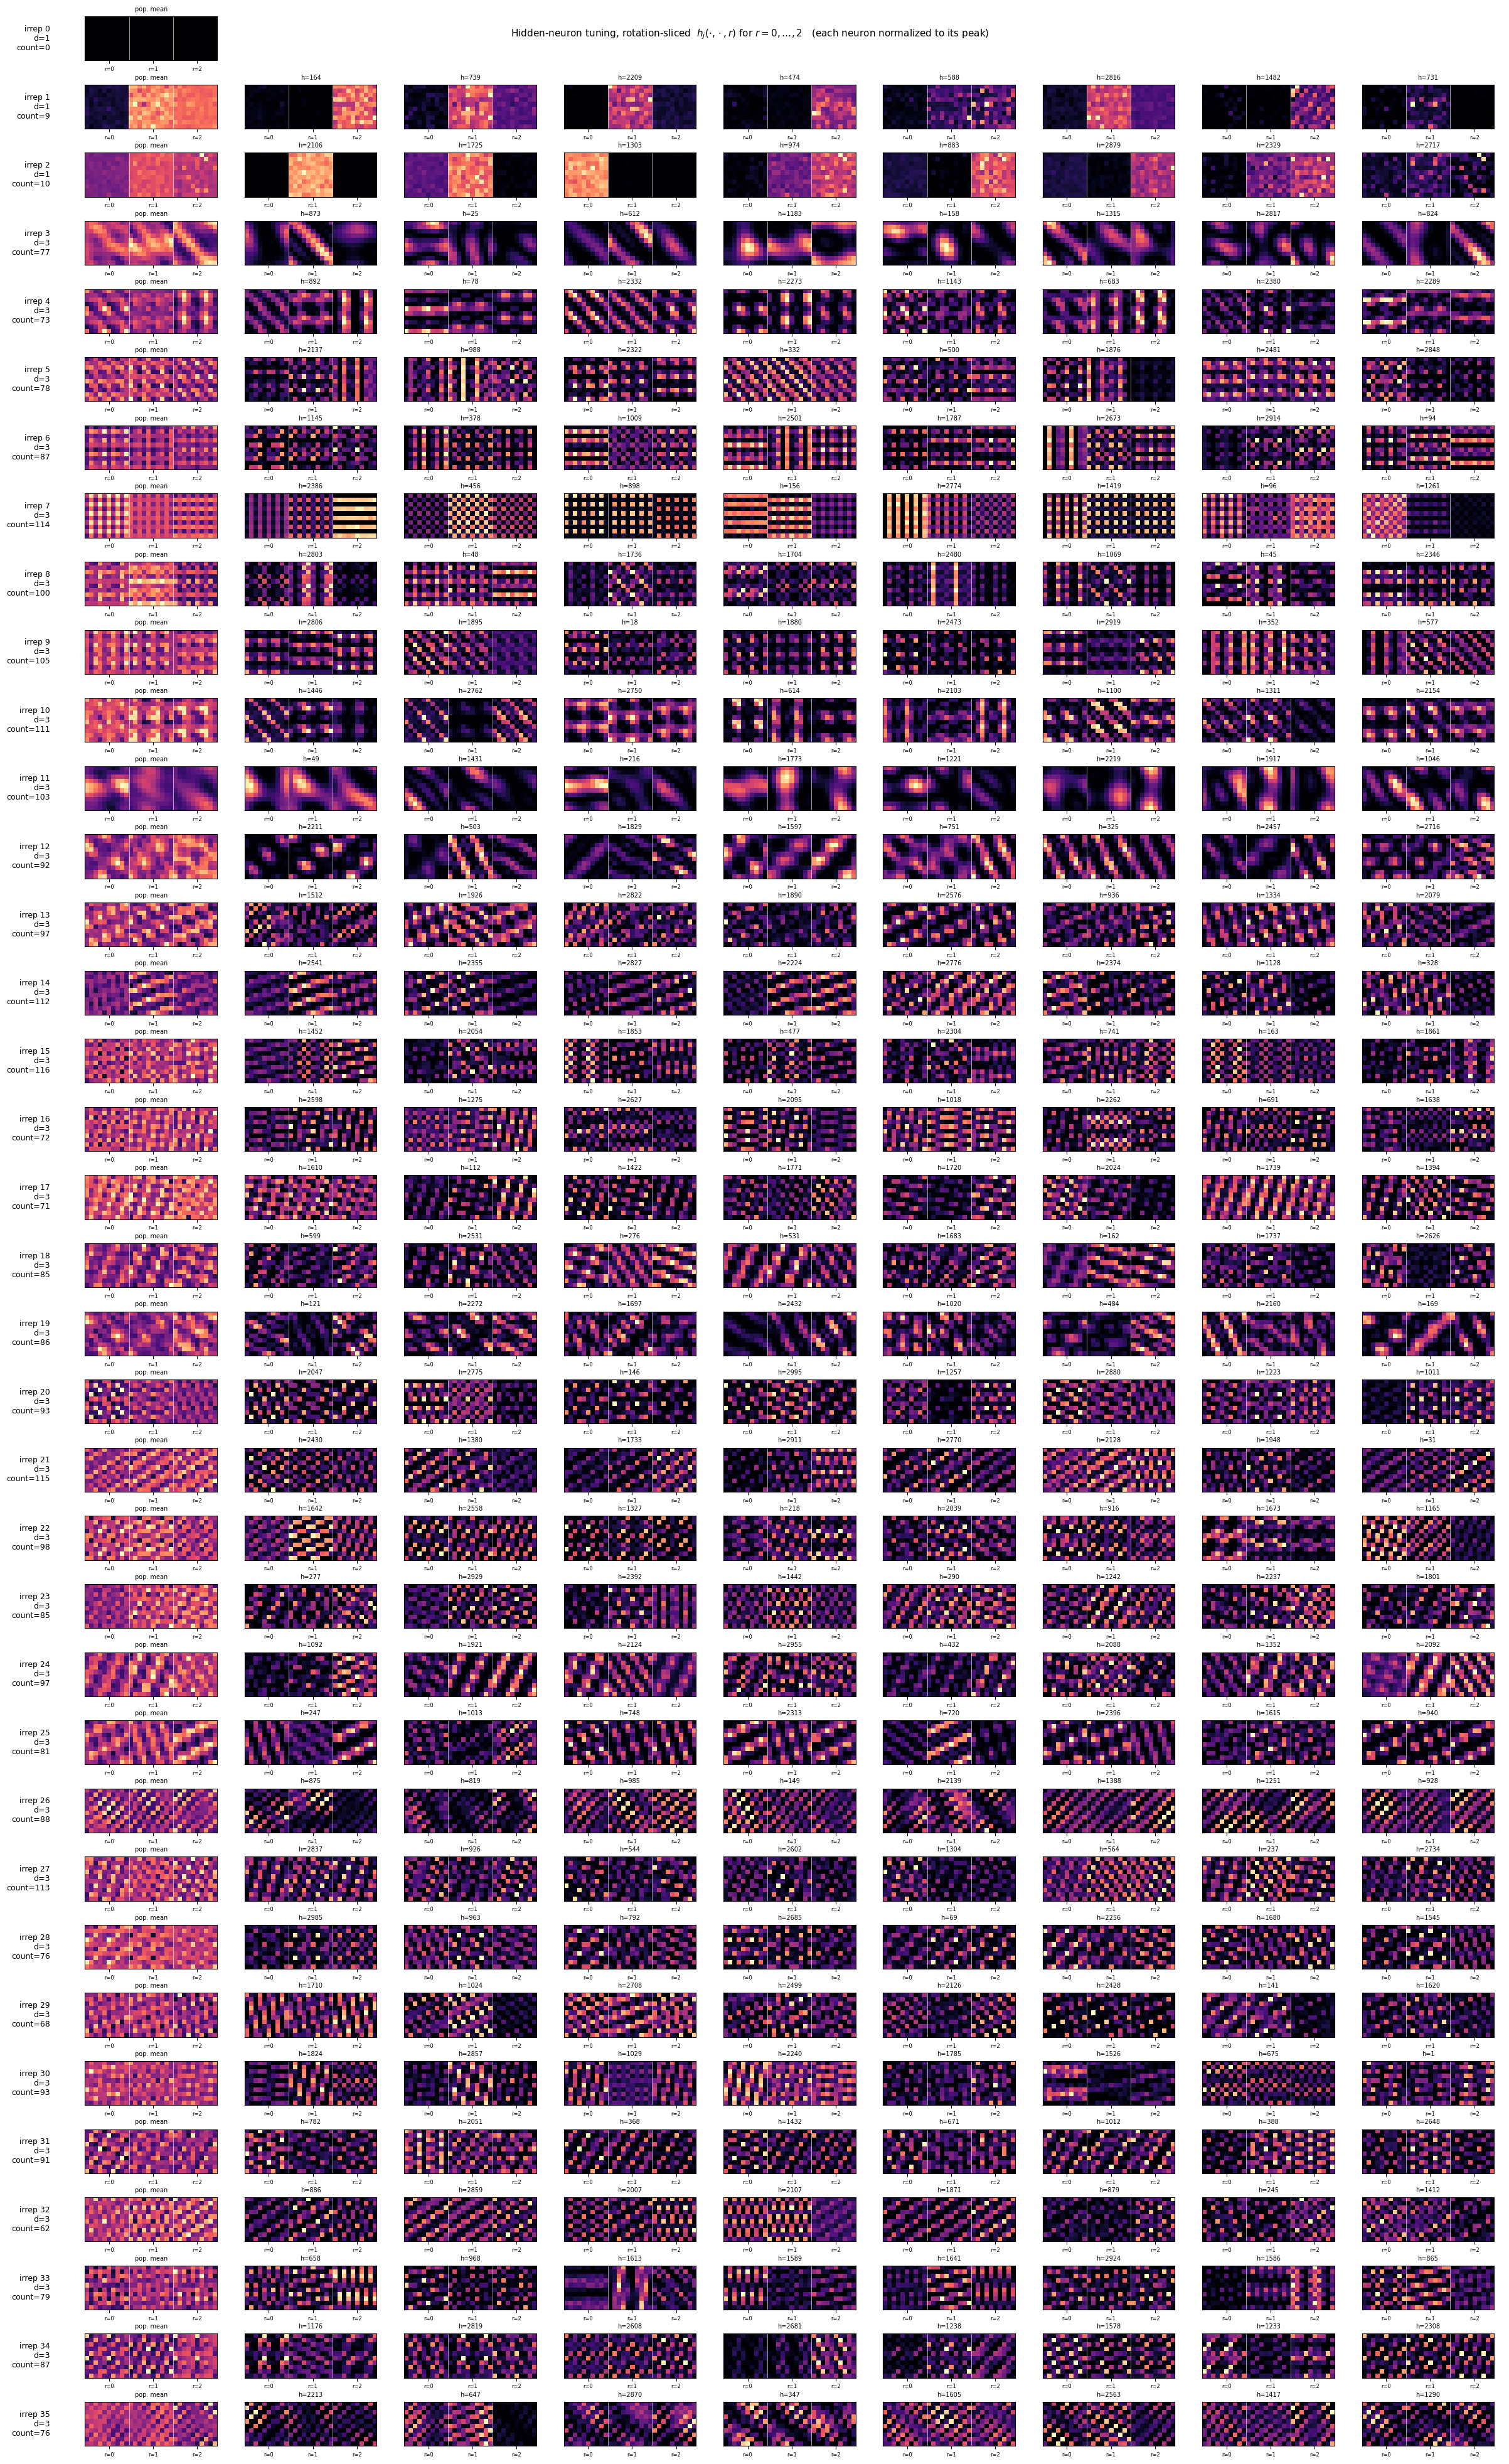

In [59]:
# === Translation tuning maps SLICED by rotation, grouped by dominant W_out irrep ===
# Each tile is h_j(·, ·, r) for r = 0, ..., m-1 laid out left-to-right (no averaging).
# Tile shape: (n, m * n).
from matplotlib.colors import Normalize

# H_rxy: (n_neurons, m, n, n) was computed in the previous cell.
def tuning_slices(arr_mnn):
    """(m, n, n) -> (n, m*n): rotation slices side by side."""
    return np.concatenate(list(arr_mnn), axis=1)

neuron_sl = np.stack([tuning_slices(H_rxy[j]) for j in range(n_neurons)])  # (H, n, m*n)

# Per-neuron normalization keeps weak/strong neurons visible at the same scale.
if NORMALIZE_PER_NEURON:
    peaks = neuron_sl.reshape(n_neurons, -1).max(axis=1)
    peaks = np.where(peaks > 1e-12, peaks, 1.0)
    neuron_sl_show = neuron_sl / peaks[:, None, None]
    vmax = 1.0
else:
    neuron_sl_show = neuron_sl
    vmax = neuron_sl.max()

norm = Normalize(vmin=0.0, vmax=vmax)
cmap = "magma"


def _draw_tuning_tile(ax, img, title=None):
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower", aspect="equal")
    for r_ in range(1, m):
        ax.axvline(r_ * n - 0.5, color="white", lw=0.6, alpha=0.7)
    ax.set_xticks([n // 2 + r_ * n for r_ in range(m)])
    ax.set_xticklabels([f"r={r_}" for r_ in range(m)], fontsize=6)
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=7)


ncols = 1 + K_MAX
# Tiles are m times wider than tall; widen the figure accordingly.
fig, axes = plt.subplots(
    n_irreps, ncols,
    figsize=(0.9 * m * ncols, 1.1 * n_irreps),
    squeeze=False,
)

for r, gid in enumerate(range(n_irreps)):
    bucket = neurons_by_irrep[gid]

    # Population-mean tuning for this irrep (left column), then sliced.
    if len(bucket) > 0:
        proto_mnn = H_rxy[bucket].mean(axis=0)               # (m, n, n)
        if NORMALIZE_PER_NEURON and proto_mnn.max() > 1e-12:
            proto_mnn = proto_mnn / proto_mnn.max()
        proto_sl = tuning_slices(proto_mnn)                  # (n, m*n)
    else:
        proto_sl = np.zeros((n, m * n))

    _draw_tuning_tile(axes[r, 0], proto_sl, title="pop. mean")
    axes[r, 0].set_ylabel(
        f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
        rotation=0, ha="right", va="center", labelpad=40, fontsize=9,
    )

    for c in range(K_MAX):
        ax = axes[r, c + 1]
        if c < len(bucket):
            j = bucket[c]
            _draw_tuning_tile(ax, neuron_sl_show[j], title=f"h={j}")
        else:
            ax.axis("off")

extra = "   (each neuron normalized to its peak)" if NORMALIZE_PER_NEURON else ""
fig.suptitle(
    rf"Hidden-neuron tuning, rotation-sliced  $h_j(\cdot, \cdot, r)$ for $r=0,\ldots,{m-1}$"
    + extra,
    fontsize=11,
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{file_tag}_activations.pdf", bbox_inches="tight")
plt.show()

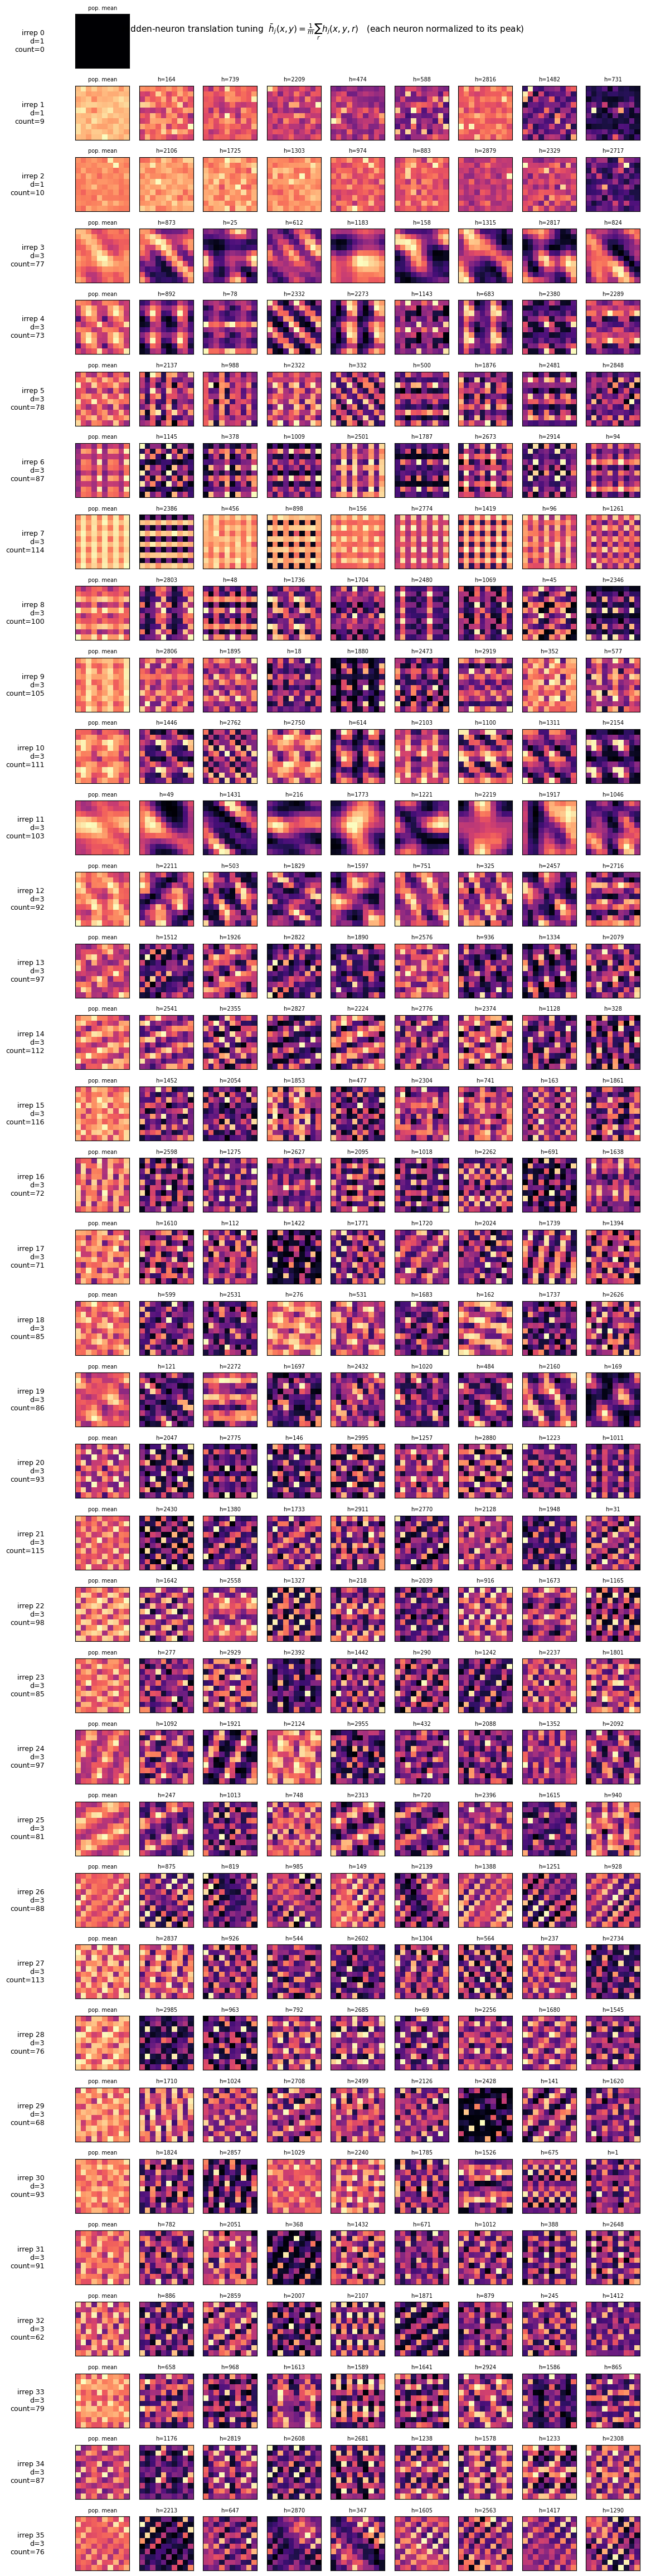

In [50]:
# === Translation tuning maps, grouped by each neuron's dominant W_out irrep ===
# Leftmost column: population-mean tuning (the "prototype" rate map for that irrep).
# Remaining columns: top-K_MAX individual neurons in that bucket.
from matplotlib.colors import Normalize

vmax = 1.0 if NORMALIZE_PER_NEURON else trans_tuning.max()
norm = Normalize(vmin=0.0, vmax=vmax)
cmap = "magma"

ncols = 1 + K_MAX
fig, axes = plt.subplots(
    n_irreps, ncols,
    figsize=(1.3 * ncols, 1.3 * n_irreps),
    squeeze=False,
)

for r, gid in enumerate(range(n_irreps)):
    bucket = neurons_by_irrep[gid]

    # Population-mean tuning for this irrep (left column)
    proto = trans_tuning[bucket].mean(axis=0) if len(bucket) > 0 else np.zeros((n, n))
    if NORMALIZE_PER_NEURON and proto.max() > 1e-12:
        proto = proto / proto.max()
    axes[r, 0].imshow(proto, cmap=cmap, norm=norm, origin="lower")
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(
        f"irrep {gid}\nd={irreps[gid].dim}\ncount={counts[gid]}",
        rotation=0, ha="right", va="center", labelpad=40, fontsize=9,
    )
    axes[r, 0].set_title("pop. mean", fontsize=7)

    for c in range(K_MAX):
        ax = axes[r, c + 1]
        if c < len(bucket):
            j = bucket[c]
            ax.imshow(trans_tuning_show[j], cmap=cmap, norm=norm, origin="lower")
            ax.set_title(f"h={j}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")

extra = "   (each neuron normalized to its peak)" if NORMALIZE_PER_NEURON else ""
fig.suptitle(
    rf"Hidden-neuron translation tuning  $\bar h_j(x,y) = \frac{{1}}{{m}}\sum_r h_j(x,y,r)$"
    + extra,
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Power Spectrum over training

Computing power at step 0 with output shape (5, 300)
powers_over_time shape: (2, 36)
sampled snapshot indices: [0 1]


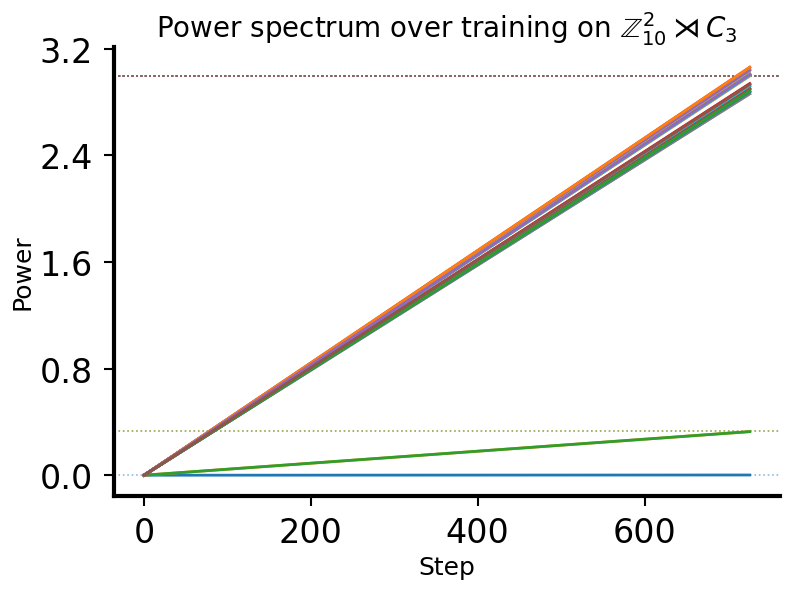

In [ ]:
# ### Power Spectrum over training ###

# powers_over_time, power_steps = viz.model_power_over_time(
#     group,
#     model=net,
#     param_history=param_history,
#     model_inputs=X_tensor,
# )

# template_pwr = group.power_spectrum(tpl)
# print(f"powers_over_time shape: {powers_over_time.shape}")
# print(f"sampled snapshot indices: {power_steps}")




# tab_colors = plt.cm.tab10.colors
# fig, ax = plt.subplots(figsize=(8, 6))

# # Map snapshot-index -> actual training step for the x-axis
# x_steps = (np.asarray(param_save_indices)[power_steps]
#            if len(param_save_indices) == len(param_history) else power_steps)

# for i in range(n_irreps):
#     color = tab_colors[i % len(tab_colors)]
#     ax.plot(x_steps, powers_over_time[:, i], color=color, lw=2,
#             label=f"irrep {i} (d={irreps[i].dim})")
#     ax.axhline(template_pwr[i], color=color, linestyle="dotted", linewidth=1.2,
#                alpha=0.5, zorder=-10)

# xlabel = "Step" if config["training"].get("mode") == "online" else "Epoch"
# ax.set_xlabel(xlabel, fontsize=18)
# ax.set_ylabel("Power", fontsize=18)
# ax.set_title(f"Power spectrum over training on {group_label_latex}", fontsize=20)
# # Legend can be huge for big n_irreps; keep it compact and only if reasonable.
# if n_irreps <= 24:
#     ax.legend(fontsize=8, title="Irrep", title_fontsize=10, loc="upper left",
#               labelspacing=0.25, ncol=2 if n_irreps > 12 else 1)
# viz.style_axes(ax)
# ax.grid(False)
# plt.tight_layout()

# if SAVE_FIGS:
#     plt.savefig(f"{FIGURES_DIR}/{file_tag}_power_spectrum.pdf", bbox_inches="tight")
# plt.show()